# Pergunta de Pesquisa 4

## Inspeção exploratória da segunda aba da base da CELESC

Antes de definir a quarta pergunta de pesquisa, será realizada uma inspeção exploratória da segunda aba disponibilizada pela CELESC.

O objetivo desta etapa é compreender sua estrutura, identificar as variáveis disponíveis e avaliar seu potencial para ampliar as análises desenvolvidas até o momento.

Essa inspeção permitirá verificar se a nova base oferece informações complementares às análises anteriores e se ela pode originar uma nova pergunta de pesquisa alinhada aos objetivos deste projeto.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
arquivo = "../data/raw/Municipio_Mensal_1T_2026.xlsx"

In [5]:
excel = pd.ExcelFile(arquivo)

In [6]:
excel.sheet_names

['Número de UC', 'Consumo MWh']

In [7]:
df = pd.read_excel(arquivo, sheet_name="Número de UC")

In [8]:
df.head()

,tipo,cod_muni,agência,núcleo,unidade,município,cod_classe,classe,1994-01-01 00:00:00,1994-02-01 00:00:00,...,2025-06-01 00:00:00,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00
0,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,1,Residencial,NaN,NaN,...,241486.0,243776.0,243281.0,251103.0,250689.963667,251050.782662,250825.349748,252565.717116,250934.065683,253503.172733
1,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,2,Industrial,NaN,NaN,...,4502.0,4490.0,4506.0,4595.0,4587.441739,4594.044461,4589.919205,4621.766646,4591.908626,4638.921394
2,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,3,Comercial,NaN,NaN,...,34472.0,34524.0,34565.0,35473.0,35414.650885,35465.623323,35433.776704,35679.636178,35449.134865,35812.069335
3,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,4,Rural,NaN,NaN,...,90.0,90.0,102.0,89.0,88.853605,88.981492,88.901591,89.518440,88.940124,89.850708
4,Cativo,1101,ARFLO,Núcleo Grande Capital,Florianópolis (sede),Florianópolis,5,Poder Público,NaN,NaN,...,1976.0,2083.0,2014.0,2084.0,2080.572053,2083.566628,2081.695674,2096.139650,2082.597949,2103.919953


In [9]:
df.shape

(3081, 395)

In [10]:
df.columns

Index([             'tipo',          'cod_muni',           'agência',
                  'núcleo',           'unidade',         'município',
              'cod_classe',            'classe', 1994-01-01 00:00:00,
       1994-02-01 00:00:00,
       ...
       2025-06-01 00:00:00, 2025-07-01 00:00:00, 2025-08-01 00:00:00,
       2025-09-01 00:00:00, 2025-10-01 00:00:00, 2025-11-01 00:00:00,
       2025-12-01 00:00:00, 2026-01-01 00:00:00, 2026-02-01 00:00:00,
       2026-03-01 00:00:00],
      dtype='object', length=395)

In [11]:
consumo = pd.read_excel(arquivo, sheet_name="Consumo MWh")

In [12]:
list(df.columns) == list(consumo.columns)

True

## Inspeção da segunda aba da base da CELESC

A inspeção exploratória da aba "Número de UC" mostrou que sua estrutura é idêntica à da aba "Consumo MWh", apresentando o mesmo número de registros, as mesmas variáveis descritivas e a mesma organização temporal.

A diferença entre as duas abas está exclusivamente na variável medida ao longo do tempo:

Consumo MWh: consumo mensal de energia elétrica;
Número de UC: quantidade mensal de unidades consumidoras.

Essa organização permite analisar dois aspectos complementares do mercado de energia elétrica catarinense: o comportamento da demanda energética e a evolução da quantidade de consumidores atendidos, utilizando a mesma estrutura espacial e temporal.

# Pergunta de Pesquisa 4

## Como as unidades consumidoras estão distribuídas entre as regiões de Santa Catarina?

---

## Objetivo

Investigar como o número de unidades consumidoras está distribuído entre as diferentes regiões de Santa Catarina, buscando identificar áreas com maior concentração de consumidores de energia elétrica e compreender a estrutura regional do mercado atendido pela CELESC.

---

## Motivação

Após compreender a distribuição do consumo de energia elétrica entre municípios e regiões do estado, o próximo passo consiste em analisar a distribuição da quantidade de unidades consumidoras.

Enquanto o consumo revela onde a demanda energética está concentrada, o número de unidades consumidoras permite compreender a dimensão do mercado atendido em cada região, servindo como base para análises futuras sobre intensidade de consumo, perfil regional e infraestrutura elétrica.

---

## Estratégia de Análise

Para responder esta pergunta serão realizadas análises buscando identificar:

- distribuição regional das unidades consumidoras;
- participação relativa de cada região no total estadual;
- regiões com maior concentração de consumidores;
- diferenças entre concentração de consumidores e concentração do consumo de energia;
- primeiras evidências sobre a estrutura regional do mercado consumidor de energia elétrica.

In [14]:
import datetime

coluna_data = max(col for col in df.columns if isinstance(col, datetime.datetime))

coluna_data

datetime.datetime(2026, 3, 1, 0, 0)

In [16]:
df.columns.tolist()

['tipo',
 'cod_muni',
 'agência',
 'núcleo',
 'unidade',
 'município',
 'cod_classe',
 'classe',
 datetime.datetime(1994, 1, 1, 0, 0),
 datetime.datetime(1994, 2, 1, 0, 0),
 datetime.datetime(1994, 3, 1, 0, 0),
 datetime.datetime(1994, 4, 1, 0, 0),
 datetime.datetime(1994, 5, 1, 0, 0),
 datetime.datetime(1994, 6, 1, 0, 0),
 datetime.datetime(1994, 7, 1, 0, 0),
 datetime.datetime(1994, 8, 1, 0, 0),
 datetime.datetime(1994, 9, 1, 0, 0),
 datetime.datetime(1994, 10, 1, 0, 0),
 datetime.datetime(1994, 11, 1, 0, 0),
 datetime.datetime(1994, 12, 1, 0, 0),
 datetime.datetime(1995, 1, 1, 0, 0),
 datetime.datetime(1995, 2, 1, 0, 0),
 datetime.datetime(1995, 3, 1, 0, 0),
 datetime.datetime(1995, 4, 1, 0, 0),
 datetime.datetime(1995, 5, 1, 0, 0),
 datetime.datetime(1995, 6, 1, 0, 0),
 datetime.datetime(1995, 7, 1, 0, 0),
 datetime.datetime(1995, 8, 1, 0, 0),
 datetime.datetime(1995, 9, 1, 0, 0),
 datetime.datetime(1995, 10, 1, 0, 0),
 datetime.datetime(1995, 11, 1, 0, 0),
 datetime.datetime(1995,

In [19]:
import os

os.listdir("../data/raw")

['Municipio_Mensal_1T_2026.xlsx']

In [21]:
os.listdir("../data")

['auxiliary', 'processed', 'raw']

In [23]:
import os

os.listdir("../data/auxiliary")

['RELATORIO_DTB_BRASIL_2025_MUNICIPIOS.xls']

In [26]:
ibge.columns.tolist()

['TÍTULO : BET - BANCO DE ESTRUTURAS TERRITORIAIS',
 'Unnamed: 1',
 'Unnamed: 2',
 'Unnamed: 3',
 'Unnamed: 4',
 'Unnamed: 5',
 'Unnamed: 6',
 'Unnamed: 7',
 'Unnamed: 8']

In [27]:
pd.Series(ibge.columns)

0    TÍTULO : BET - BANCO DE ESTRUTURAS TERRITORIAIS
1                                         Unnamed: 1
2                                         Unnamed: 2
3                                         Unnamed: 3
4                                         Unnamed: 4
5                                         Unnamed: 5
6                                         Unnamed: 6
7                                         Unnamed: 7
8                                         Unnamed: 8
dtype: str

In [28]:
excel_ibge = pd.ExcelFile("../data/auxiliary/RELATORIO_DTB_BRASIL_2025_MUNICIPIOS.xls")

excel_ibge.sheet_names

['DTB_Municípios']

In [31]:
ibge = excel_ibge.parse(0, header=None)

ibge.head(15)

,0,1,2,3,4,5,6,7,8
0,TÍTULO : BET - BANCO DE ESTRUTURAS TERRITORIAIS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELATÓRIO DE DIVISÃO TERRITORIAL BRASILEIRA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,UF: 99 - BRASIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DATA BASE: 31/12/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,UF,Nome_UF,Região Geográfica Intermediária,Nome Região Geográfica Intermediária,Região Geográfica Imediata,Nome Região Geográfica Imediata,Município,Código Município Completo,Nome_Município
7,11,Rondônia,1102,Ji-Paraná,110005,Cacoal,00015,1100015,Alta Floresta D'Oeste
8,11,Rondônia,1102,Ji-Paraná,110005,Cacoal,00379,1100379,Alto Alegre dos Parecis
9,11,Rondônia,1101,Porto Velho,110002,Ariquemes,00403,1100403,Alto Paraíso


In [32]:
ibge = excel_ibge.parse(0, header=6)

ibge.head()

,UF,Nome_UF,Região Geográfica Intermediária,Nome Região Geográfica Intermediária,Região Geográfica Imediata,Nome Região Geográfica Imediata,Município,Código Município Completo,Nome_Município
0,11,Rondônia,1102,Ji-Paraná,110005,Cacoal,15,1100015,Alta Floresta D'Oeste
1,11,Rondônia,1102,Ji-Paraná,110005,Cacoal,379,1100379,Alto Alegre dos Parecis
2,11,Rondônia,1101,Porto Velho,110002,Ariquemes,403,1100403,Alto Paraíso
3,11,Rondônia,1102,Ji-Paraná,110004,Ji-Paraná,346,1100346,Alvorada D'Oeste
4,11,Rondônia,1101,Porto Velho,110002,Ariquemes,23,1100023,Ariquemes


In [33]:
ibge.columns

Index(['UF', 'Nome_UF', 'Região Geográfica Intermediária',
       'Nome Região Geográfica Intermediária', 'Região Geográfica Imediata',
       'Nome Região Geográfica Imediata', 'Município',
       'Código Município Completo', 'Nome_Município'],
      dtype='str')

In [34]:
ibge_sc = ibge.loc[
    ibge["Nome_UF"] == "Santa Catarina",
    [
        "Nome_Município",
        "Nome Região Geográfica Intermediária",
        "Nome Região Geográfica Imediata",
    ],
]

ibge_sc.head()

,Nome_Município,Nome Região Geográfica Intermediária,Nome Região Geográfica Imediata
4311,Abdon Batista,Chapecó,Joaçaba - Herval d'Oeste
4312,Abelardo Luz,Chapecó,Xanxerê
4313,Agrolândia,Blumenau,Rio do Sul
4314,Agronômica,Blumenau,Rio do Sul
4315,Água Doce,Chapecó,Joaçaba - Herval d'Oeste


In [36]:
base_uc = df.merge(ibge_sc, left_on="município", right_on="Nome_Município", how="left")

base_uc.shape

(3081, 398)

In [37]:
base_uc[
    [
        "município",
        "Nome Região Geográfica Intermediária",
        "Nome Região Geográfica Imediata",
    ]
].head()

,município,Nome Região Geográfica Intermediária,Nome Região Geográfica Imediata
0,Florianópolis,Florianópolis,Florianópolis
1,Florianópolis,Florianópolis,Florianópolis
2,Florianópolis,Florianópolis,Florianópolis
3,Florianópolis,Florianópolis,Florianópolis
4,Florianópolis,Florianópolis,Florianópolis


In [38]:
uc_regiao = (
    base_uc.groupby("Nome Região Geográfica Intermediária")[coluna_data]
    .sum()
    .reset_index()
    .rename(columns={coluna_data: "Unidades Consumidoras"})
)

uc_regiao

,Nome Região Geográfica Intermediária,Unidades Consumidoras
0,Blumenau,1.093888e+06
1,Caçador,1.034995e+05
2,Chapecó,4.737991e+05
3,Criciúma,3.107725e+05
4,Florianópolis,6.855652e+05
5,Joinville,6.842433e+05
6,Lages,1.758026e+05


In [39]:
uc_regiao["Participação (%)"] = (
    uc_regiao["Unidades Consumidoras"] / uc_regiao["Unidades Consumidoras"].sum() * 100
)

In [40]:
uc_regiao = uc_regiao.sort_values(
    by="Unidades Consumidoras", ascending=False
).reset_index(drop=True)

In [41]:
uc_regiao["Unidades Consumidoras"] = (
    uc_regiao["Unidades Consumidoras"].round(0).astype(int)
)

uc_regiao["Participação (%)"] = uc_regiao["Participação (%)"].round(2)

uc_regiao

,Nome Região Geográfica Intermediária,Unidades Consumidoras,Participação (%)
0,Blumenau,1093888,31.01
1,Florianópolis,685565,19.43
2,Joinville,684243,19.40
3,Chapecó,473799,13.43
4,Criciúma,310773,8.81
5,Lages,175803,4.98
6,Caçador,103499,2.93


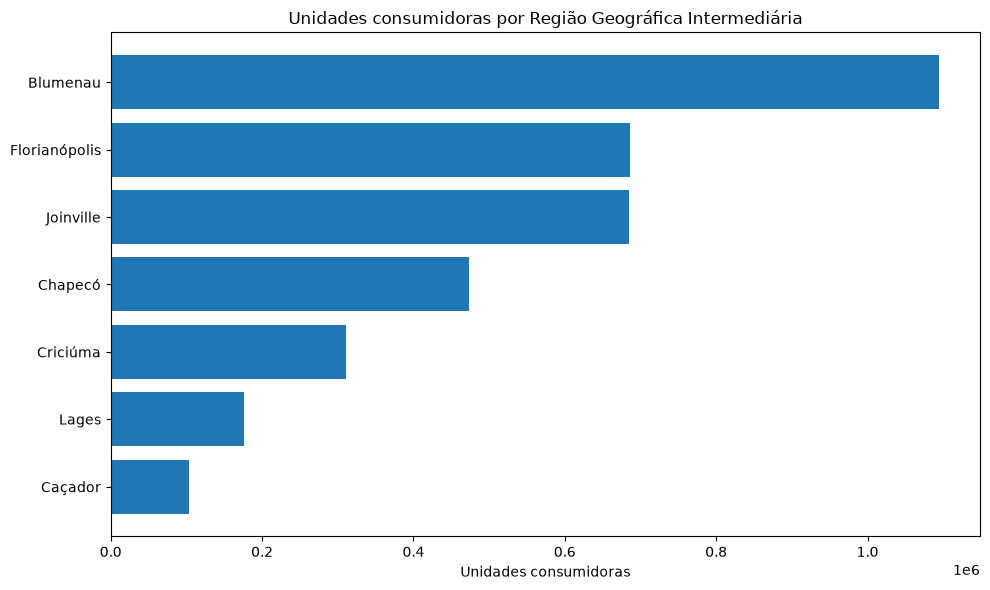

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    uc_regiao["Nome Região Geográfica Intermediária"],
    uc_regiao["Unidades Consumidoras"],
)

plt.title("Unidades consumidoras por Região Geográfica Intermediária")
plt.xlabel("Unidades consumidoras")
plt.ylabel("")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Principais evidências

A distribuição das unidades consumidoras apresenta concentração nas Regiões Geográficas Intermediárias de Blumenau, Florianópolis e Joinville, que reúnem a maior parcela das unidades consumidoras do estado.

Blumenau lidera com 31,01% das unidades consumidoras, enquanto Florianópolis (19,43%) e Joinville (19,40%) apresentam participações bastante semelhantes, formando um segundo nível de concentração regional.

As demais regiões possuem participações progressivamente menores, evidenciando uma distribuição regional heterogênea das unidades consumidoras em Santa Catarina.

In [43]:
top3 = uc_regiao.head(3)

top3["Participação (%)"].sum().round(2)

np.float64(69.84)

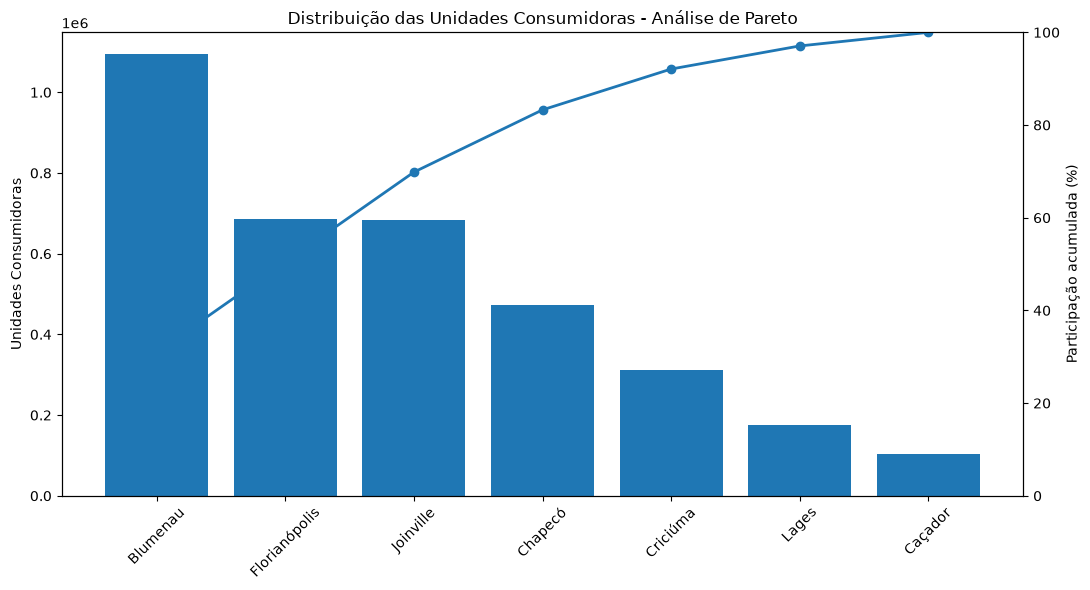

In [44]:
import matplotlib.pyplot as plt

# Dados
pareto = uc_regiao.copy()
pareto["Participação Acumulada (%)"] = pareto["Participação (%)"].cumsum()

# Figura
fig, ax1 = plt.subplots(figsize=(11, 6))

# Barras
ax1.bar(pareto["Nome Região Geográfica Intermediária"], pareto["Unidades Consumidoras"])

ax1.set_ylabel("Unidades Consumidoras")
ax1.set_xlabel("")
ax1.tick_params(axis="x", rotation=45)

# Linha acumulada
ax2 = ax1.twinx()

ax2.plot(
    pareto["Nome Região Geográfica Intermediária"],
    pareto["Participação Acumulada (%)"],
    marker="o",
    linewidth=2,
)

ax2.set_ylabel("Participação acumulada (%)")
ax2.set_ylim(0, 100)

plt.title("Distribuição das Unidades Consumidoras - Análise de Pareto")
plt.tight_layout()
plt.show()

## Evidência

O gráfico de Pareto evidencia elevada concentração regional das unidades consumidoras em Santa Catarina. As três Regiões Geográficas Intermediárias com maior número de consumidores (Blumenau, Florianópolis e Joinville) concentram aproximadamente 69,8% das unidades consumidoras do estado, indicando que a maior parte do mercado consumidor está concentrada em poucos polos regionais.

## Conclusão

A análise da distribuição das unidades consumidoras evidenciou que o mercado consumidor de energia elétrica em Santa Catarina apresenta elevada concentração regional.

As Regiões Geográficas Intermediárias de Blumenau, Florianópolis e Joinville concentram aproximadamente **69,84%** das unidades consumidoras do estado, configurando os principais polos consumidores sob a perspectiva do número de ligações atendidas.

O gráfico de Pareto reforça essa concentração ao demonstrar que poucas regiões reúnem a maior parte das unidades consumidoras, enquanto as demais apresentam participações progressivamente menores.

Esses resultados complementam as análises anteriores sobre a distribuição do consumo de energia elétrica e constituem evidências iniciais sobre a estrutura regional do mercado consumidor catarinense, oferecendo uma base para análises futuras envolvendo intensidade de consumo, infraestrutura elétrica e planejamento energético.